(8807, 12)
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN  

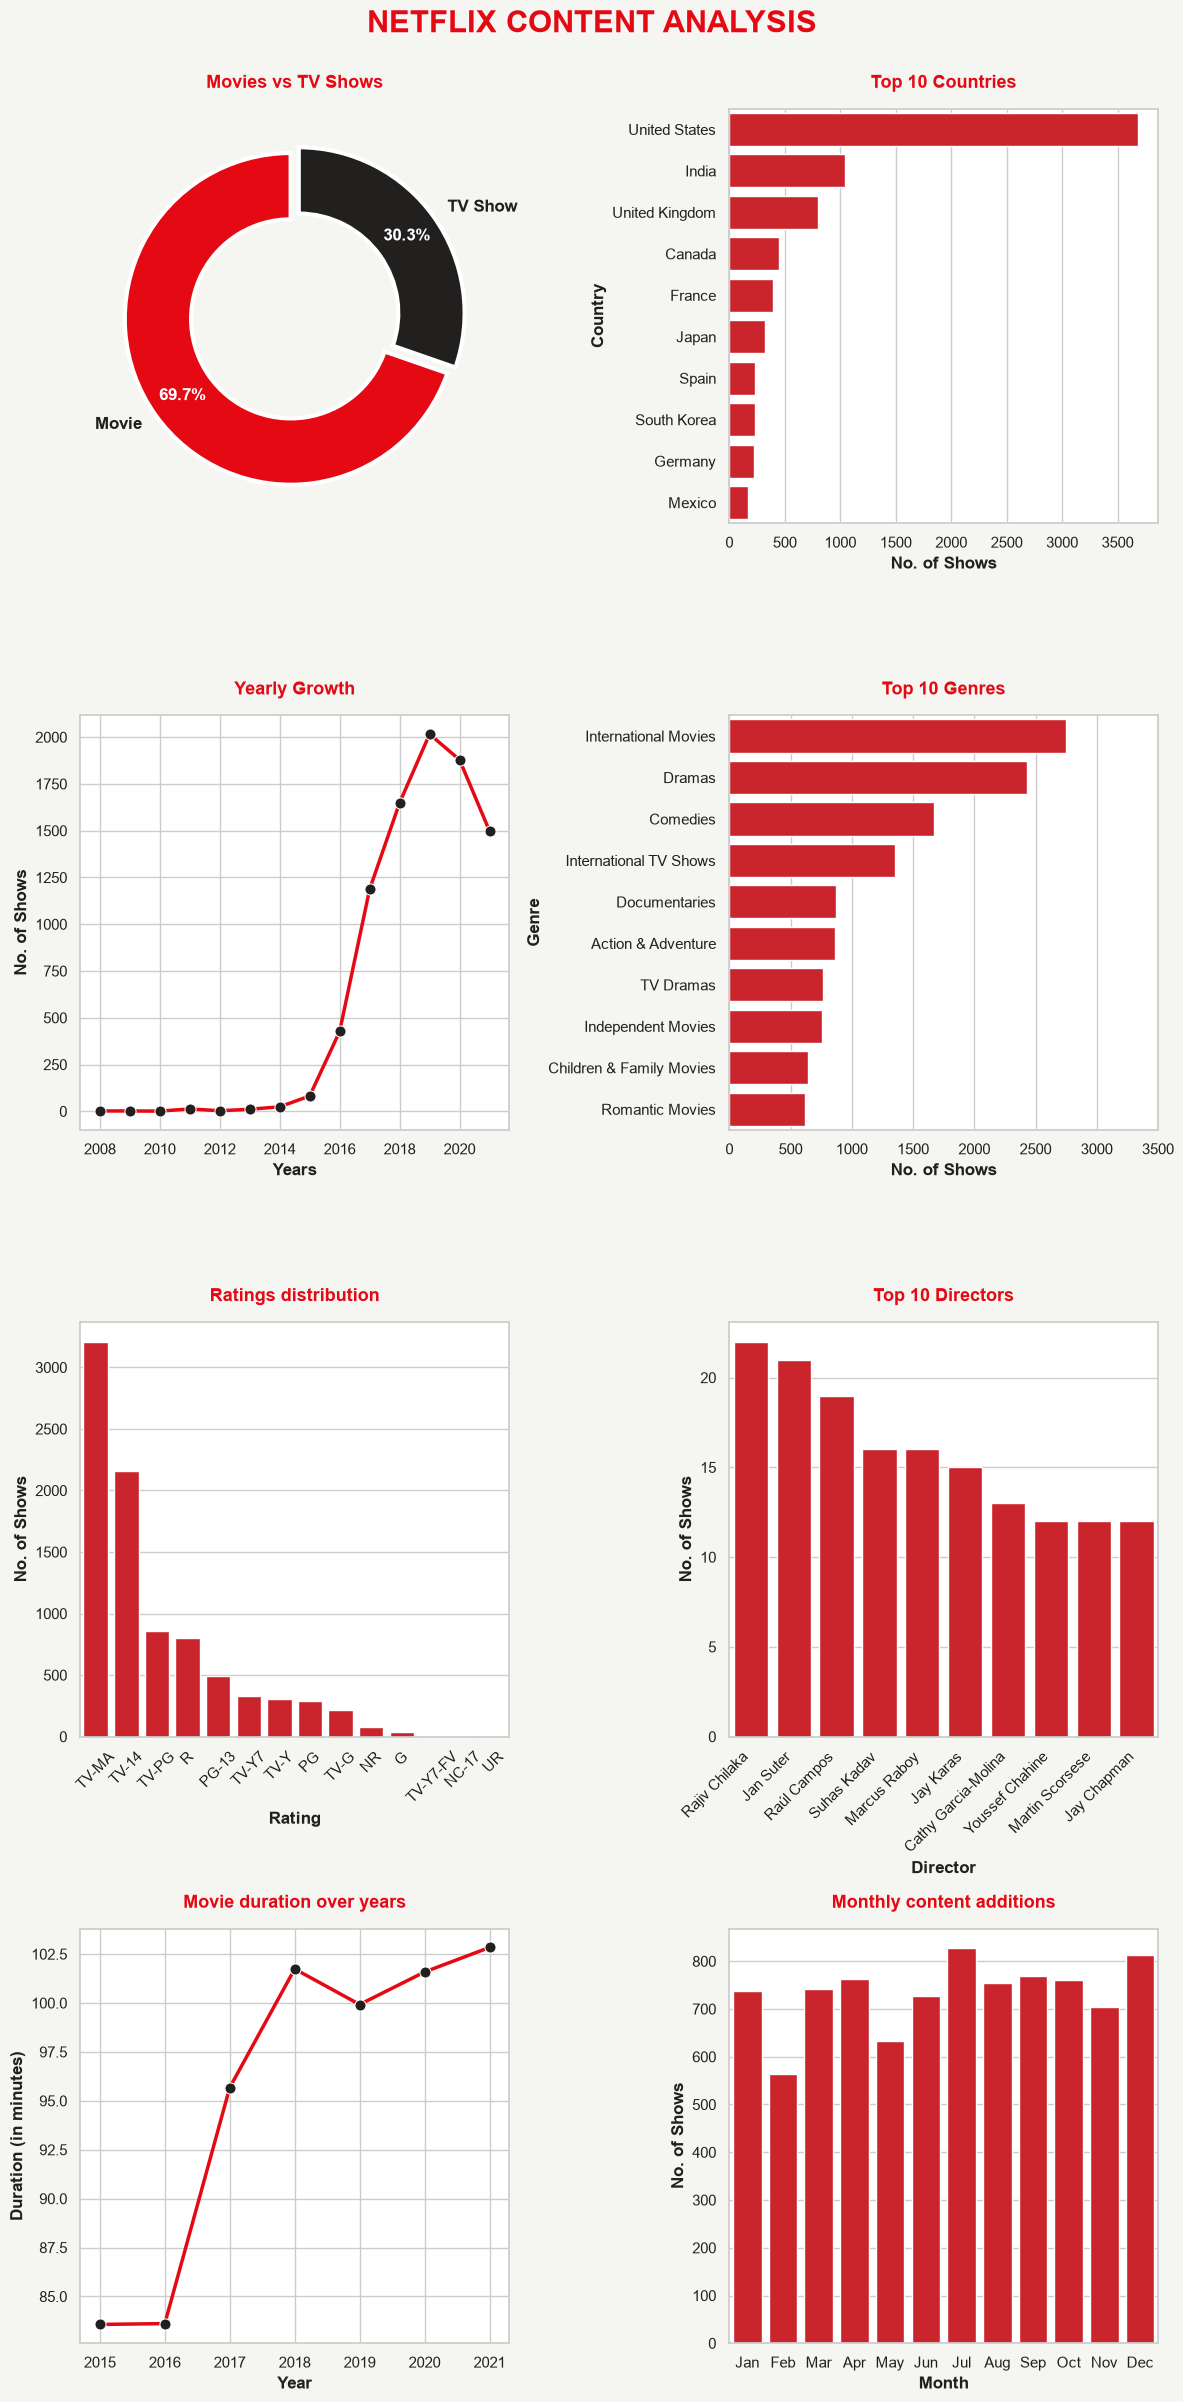

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
NETFLIX_DARK = '#221F1F'
NETFLIX_GRAY = '#564D4D'

def style_axis(ax, title):
    ax.set_title(title, fontsize=13, fontweight='bold', color=NETFLIX_RED, pad=15)
    ax.xaxis.label.set_color(NETFLIX_DARK)
    ax.yaxis.label.set_color(NETFLIX_DARK)
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')
    ax.tick_params(axis='x', colors=NETFLIX_DARK)
    ax.tick_params(axis='y', colors=NETFLIX_DARK)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] =(12,24)
fig,axes = plt.subplots(nrows=4,ncols=2)
fig.patch.set_facecolor('#F5F5F1')  

df=pd.read_csv('netflix_titles.csv')

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.isnull().sum())

df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%b')

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df.dropna(subset=['date_added','duration'],inplace=True)

df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(int)

df_movies = df[df['type'] == "Movie"].copy()
df_shows = df[df['type'] == "TV Show"].copy()

print("Total after Cleaning: ", df.shape)
print("Movies: ", len(df_movies))
print("TV shows: ", len(df_shows))
print("Null Values after Cleaning: ", df.isnull().sum())

print(df['type'].value_counts())
print("Movies vs TV Shows — which dominates?")
print(df['type'].value_counts().idxmax())

print('Top 10 countries producing most content?')
print(df['country'].str.split(', ').explode().value_counts().head(10))

print('How has Netflix library grown yearly?')
print(df.groupby('year_added')['show_id'].count())

print('Top 10 most common genres?')
print(df['listed_in'].str.split(', ').explode().value_counts().head(10))

print(df['rating'].value_counts())
print('Which ratings dominate?')
print(df['rating'].value_counts().idxmax())

print('Top 10 directors with most content?')
print(df[df['director']!='Unknown']['director'].str.split(', ').explode().value_counts().head(10))

print('Average movie duration in minutes?')
print(df[df['type']=='Movie']['duration_int'].mean())

print('Which month has most content added?')
print(df['month_name'].value_counts().idxmax())

print('Are movies getting shorter over time?')
print(df[df['type']=='Movie'][['year_added','duration_int']].groupby('year_added')['duration_int'].mean())
print('No')

print('Your recommendation — what should Netflix produce more of? (based on your analysis so far!)')
print('TV-MA i.e Adult Movies')

wedges,texts,autotexts =  axes[0,0].pie(
    df['type'].value_counts().values,
    labels =df['type'].value_counts().index,
    autopct = '%1.1f%%',startangle = 90,
    colors=[NETFLIX_RED, NETFLIX_DARK],
    wedgeprops = dict(width=0.4, edgecolor='white',linewidth=3),
    textprops=dict(fontsize=12, fontweight='bold'),
    pctdistance=0.80, explode=(0.03,0.03)
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
for text in texts:
    text.set_color(NETFLIX_DARK)
    text.set_fontweight('bold')
style_axis(axes[0,0],'Movies vs TV Shows')

top_countries = df[df['country']!='Unknown']['country'].str.split(', ').explode().value_counts().head(10)
sns.barplot(x=top_countries.values,y=top_countries.index,ax=axes[0,1],color=NETFLIX_RED)
axes[0,1].set_xticks(range(0,4000,500))
axes[0,1].set_xlabel('No. of Shows')
axes[0,1].set_ylabel('Country')
style_axis(axes[0,1],'Top 10 Countries')

yearly_counts = df.groupby('year_added')['show_id'].count().reset_index()
yearly_counts['year_added']=yearly_counts['year_added'].astype(int)
sns.lineplot(data=yearly_counts,x='year_added',y='show_id',ax=axes[1,0],marker='o',color=NETFLIX_RED, linewidth=2.5, markerfacecolor=NETFLIX_DARK, markersize=8)
years= yearly_counts['year_added']
axes[1,0].set_xticks(range(years.min(),years.max()+1,2))
axes[1,0].set_xlabel('Years')
axes[1,0].set_ylabel('No. of Shows')
style_axis(axes[1,0],'Yearly Growth')

top_genres = df['listed_in'].str.split(', ').explode().value_counts().head(10).reset_index()
sns.barplot(data=top_genres,y='listed_in',x='count',ax=axes[1,1],color=NETFLIX_RED)
axes[1,1].set_ylabel('Genre')
axes[1,1].set_xlabel('No. of Shows')
axes[1,1].set_xticks(range(0,4000,500))
style_axis(axes[1,1],'Top 10 Genres')

ratings_dis = df['rating'].value_counts().reset_index()
sns.barplot(data=ratings_dis,x='rating',y='count',ax=axes[2,0],color=NETFLIX_RED)
axes[2,0].tick_params(axis='x',rotation=45)
axes[2,0].set_xlabel('Rating')
axes[2,0].set_ylabel('No. of Shows')
style_axis(axes[2,0],'Ratings distribution')

directors = df[df['director']!='Unknown']['director'].str.split(', ').explode().value_counts().head(10).reset_index()
sns.barplot(data=directors,x='director',y='count',ax=axes[2,1],color=NETFLIX_RED)
plt.setp(axes[2,1].get_xticklabels(),rotation=45,ha='right')
axes[2,1].set_xlabel('Director')
axes[2,1].set_ylabel('No. of Shows')
style_axis(axes[2,1],'Top 10 Directors')

movie_counts = df[df['type']=='Movie'].groupby('year_added').size()
valid_years = movie_counts[movie_counts >= 30].index
movie_duration = (df[(df['type']=='Movie') & (df['year_added'].isin(valid_years))].groupby('year_added')['duration_int'].mean().reset_index())
sns.lineplot(data=movie_duration,x='year_added',y='duration_int',marker='o',ax=axes[3,0],color=NETFLIX_RED, linewidth=2.5, markerfacecolor=NETFLIX_DARK, markersize=8)
axes[3,0].set_xlabel('Year')
axes[3,0].set_ylabel('Duration (in minutes)')
style_axis(axes[3,0],'Movie duration over years')

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)
monthly = df['month_name'].value_counts(sort=False).reset_index()
sns.barplot(data=monthly, x='month_name', y='count', ax=axes[3,1], color=NETFLIX_RED)
axes[3,1].set_xlabel('Month')
axes[3,1].set_ylabel('No. of Shows')
style_axis(axes[3,1],'Monthly content additions')

fig.suptitle('NETFLIX CONTENT ANALYSIS', fontsize=22, fontweight='bold', color=NETFLIX_RED,y=1.00)
plt.tight_layout()
plt.savefig('netflix_dashboard.png', dpi=300, bbox_inches='tight', facecolor='#F5F5F1')
plt.show()